In [1]:
#IMPORTS
%matplotlib widget
import re
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import hilbert
import ipywidgets as widgets

In [2]:
#NAMING SETUP

base_dir = Path("metingen")

position_names = [f"0-{i}" for i in range(1, 5)] + [f"{i}-4" for i in range(1, 5)]

def numbered_names(prefix, count):
    return [prefix] + [f"{prefix} ({i})" for i in range(1, count)]

raw_source_names = numbered_names("usr_wf_C1_data", 3) #3 raw replicate files
fft_source_names = numbered_names("usr_wf_F1_data", 3) #3 fft replicate files

In [3]:
#LENGTHS

length_pattern = re.compile(r"(\d+(?:\.\d+)?)\s*cm")

def parse_length(folder_name):
    match = length_pattern.search(folder_name)
    if match:
        return float(match.group(1))
    return None

In [4]:
#FORCES

g = 9.81 #m/s
notch_to_ratio = {0: 0, 1: 4, 2: 6, 3: 8, 4: 10} #notch to lever ratio
gewicht_1 = 1.0468 #kg
gewicht_2 = 1.0436 #kg

def position_force(position):
    w2_notch, w1_notch = (int(n) for n in position.split("-"))
    return gewicht_1*g*notch_to_ratio[w1_notch]+gewicht_2*g*notch_to_ratio[w2_notch]

forces_arr = np.array([position_force(p) for p in position_names], dtype=float)

In [5]:
#FOLDER NAMES AND LENGTHS

cm_folders = sorted(f for f in base_dir.iterdir() if f.is_dir() and "23" not in f.name)

length_names_sorted = [f.name for f in cm_folders]
lengths_arr = np.array([parse_length(name) for name in length_names_sorted])

In [6]:
#GET SHAPE

def find_shape(source_names):
    for cm_folder in cm_folders:
        for position in position_names:
            position_folder = cm_folder / f"metingen {position}"
            for source_name in source_names:
                file_path = position_folder / f"{source_name}.csv"
                if file_path.exists():
                    return np.loadtxt(file_path, skiprows=12, delimiter=",").shape

raw_shape = find_shape(raw_source_names)
fft_shape = find_shape(fft_source_names)

In [7]:
#PREALLOCATE FINAL ARRAYS

n_lengths = len(cm_folders)
n_positions = len(position_names)
n_replicates = 3

raw_array = np.full((n_lengths, n_positions, n_replicates, *raw_shape), np.nan)
fft_array = np.full((n_lengths, n_positions, n_replicates, *fft_shape), np.nan)

In [8]:
#LOAD FILES INTO ARRAY SLOTS

for i, cm_folder in enumerate(cm_folders):
    print(f"Processing folder: {cm_folder.name}")
    for j, position in enumerate(position_names):
        position_folder = cm_folder / f"metingen {position}"
        for r, source_name in enumerate(raw_source_names, start=1):
            file_path = position_folder / f"{source_name}.csv"
            if file_path.exists():
                raw_array[i, j, r-1] = np.loadtxt(file_path, skiprows=12, delimiter=",")
        for r, source_name in enumerate(fft_source_names, start=1):
            file_path = position_folder / f"{source_name}.csv"
            if file_path.exists():
                fft_array[i, j, r-1] = np.loadtxt(file_path, skiprows=12, delimiter=",")

print("raw_array shape:", raw_array.shape)
print("fft_array shape:", fft_array.shape)

Processing folder: metingen 25.5 cm
Processing folder: metingen 27 cm
Processing folder: metingen 28.5 cm
Processing folder: metingen 30 cm
Processing folder: metingen 31.5 cm
raw_array shape: (5, 8, 3, 10000, 2)
fft_array shape: (5, 8, 3, 4096, 5)


In [9]:
#METADATA GRIDS

length_grid = np.broadcast_to(lengths_arr[:, None], (n_lengths, n_positions))*10**-2
force_grid = np.broadcast_to(forces_arr[None, :], (n_lengths, n_positions))

In [10]:
#TRIMMING DATA

def manual_trim(margin):
    n_lengths, n_positions, n_replicates, n_samples_raw, n_cols_raw = raw_array.shape
    start_indices = np.zeros((n_lengths, n_positions, n_replicates), dtype=int)

    for i in range(n_lengths):
        for j in range(n_positions):
            for r in range(n_replicates):
                start_indices[i, j, r] = margin

    #every signal keeps the same number of points after its own start, so the result stays rectangular
    trimmed_length = n_samples_raw - start_indices.max()
    raw_trimmed = np.full((n_lengths, n_positions, n_replicates, trimmed_length, n_cols_raw), np.nan)

    for i in range(n_lengths):
        for j in range(n_positions):
            for r in range(n_replicates):
                start = start_indices[i, j, r]
                if start >= n_samples_raw:
                    continue
                raw_trimmed[i, j, r] = raw_array[i, j, r, start:start + trimmed_length, :]

    return raw_trimmed, trimmed_length

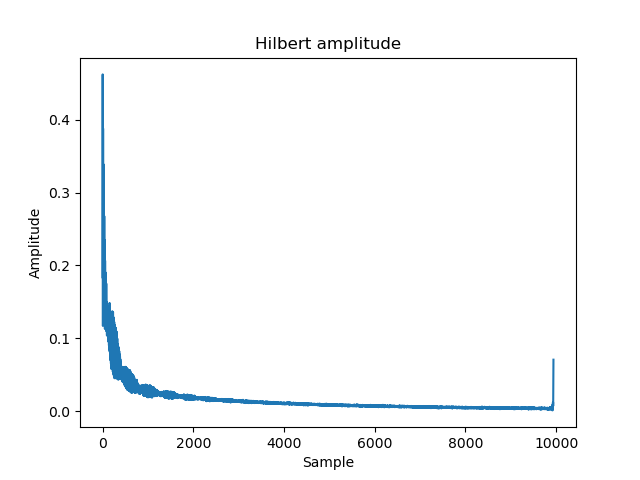

In [11]:
raw_trim , trim_L = manual_trim(60)

b = hilbert(raw_trim)
i = 0   # eerste lengte
j = 0   # eerste positie
r = 0   # eerste replicaat
col = 1 # kolom met het signaal

signal = raw_trim[i, j, r, :, col]

analytic = hilbert(signal)
amplitude = np.abs(analytic)

plt.plot(amplitude)
plt.title("Hilbert amplitude")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

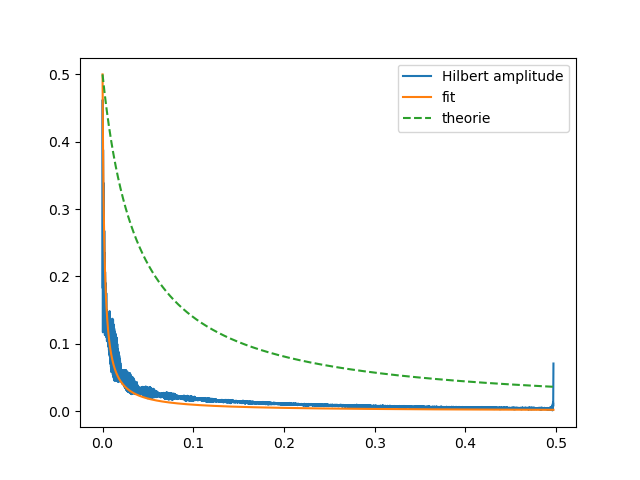

In [12]:
C_w = 1.2
rho = 1.204
D = 0.001
mu = 0.015
n = 1
U_0 = 0.5

m1 = 1.0467
m2 = 1.0436
g = 9.81

T1 = g*4*m1
T2 = g*6*m1
T3 = g*8*m1
T4 = g*10*m1
T5 = T4 + g*4*m2
T6 = T4 + g*6*m2
T7 = T4 + g*8*m2
T8 = T4 + g*10*m2

T_array = np.array([T1, T2, T3, T4, T5, T6, T7, T8])

def alpha_theory(L, T):
    return (2*C_w*rho*D*n/(3*mu*L**2))*np.sqrt(T/mu)

def theory_amp(t, alpha, U0=U_0):
    return U0 / (alpha*U0*t + 1)

# -----------------------------
# Kies één meting
# -----------------------------
i = 0       # lengte-index
j = 0       # positie-index (T1)
r = 0       # replicaat
col = 1     # signaalkolom

signal = raw_trim[i, j, r, :, col]
analytic = hilbert(signal)
envelope = np.abs(analytic)

fs = 20000   # voorbeeld sampling freq
t = np.arange(len(envelope)) / fs

L = length_grid[i, j]
T = T_array[j]

alpha_th = alpha_theory(L, T)

from scipy.optimize import curve_fit
popt, pcov = curve_fit(theory_amp, t, envelope, p0=[alpha_th])
alpha_fit = popt[0]

plt.figure()

plt.plot(t, envelope, label="Hilbert amplitude")
plt.plot(t, theory_amp(t, alpha_fit), label="fit")
plt.plot(t, theory_amp(t, alpha_th), "--", label="theorie")
plt.legend()
plt.show()
